# Deep Learning: A Comprehensive Guide

## Chapter 13 — Reinforcement Learning

### Hands-On Exploration: Watching an Agent Learn

### `hands_on_ch13.ipynb`

This exploration builds direct intuition for how RL agents learn — how exploration affects the speed and quality of learning, how the reward function shapes behavior, and how the gap between a specified reward and the true objective can produce unexpected outcomes.

## Learning Objectives

By the end of this notebook, you should be able to:

- Train a DQN agent on CartPole and interpret its learning curve
- Compare how different exploration (epsilon-decay) schedules affect learning speed and final performance
- Observe reward hacking-like behavior produced by a shaped reward function

## Prerequisites

- Python 3.9+, `numpy`, `matplotlib`, `tensorflow`
- `gymnasium` (the maintained successor to OpenAI Gym) — install with `pip install gymnasium`
- No GPU required

## About This Notebook

Unlike several earlier chapters, this activity needs **no internet access and no pretrained weights** — `gymnasium`'s CartPole environment is pure physics simulation that ships with the package, and we train the DQN agent ourselves, from scratch, in this notebook. This is the genuine chapter activity, not a fallback.

## Setup — Imports and Reproducibility

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
import random

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

%matplotlib inline

GYM_AVAILABLE = False
try:
    import gymnasium as gym
    GYM_AVAILABLE = True
except ImportError:
    print("gymnasium not installed. Install with: pip install gymnasium")

TF_AVAILABLE = False
try:
    import tensorflow as tf
    from tensorflow.keras import layers, models
    TF_AVAILABLE = True
    tf.random.set_seed(SEED)
except ImportError:
    print("TensorFlow not installed. Install with: pip install tensorflow")


I0000 00:00:1788481727.208825    2991 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788481727.255535    2991 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1788481728.612286    2991 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## A Small DQN Implementation

A compact Deep Q-Network: a small feedforward network estimates the value of each action given the cart's state, trained with experience replay and an epsilon-greedy exploration policy. Episodes are capped at 200 timesteps (instead of CartPole's default 500) purely to keep total notebook runtime short -- the learning dynamics described in the chapter are already fully visible within 200 steps.

In [2]:
if GYM_AVAILABLE and TF_AVAILABLE:
    MAX_STEPS = 200

    def build_q_network(state_dim, n_actions):
        model = models.Sequential([
            layers.Input(shape=(int(state_dim),)),
            layers.Dense(24, activation="relu"),
            layers.Dense(24, activation="relu"),
            layers.Dense(int(n_actions), activation="linear"),
        ])
        model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="mse")
        return model

    def train_dqn(env, n_episodes, epsilon_decay_episodes, gamma=0.95, batch_size=32,
                  epsilon_start=1.0, epsilon_end=0.05, seed=0):
        rng = np.random.RandomState(seed)
        state_dim = env.observation_space.shape[0]
        n_actions = env.action_space.n

        q_net = build_q_network(state_dim, n_actions)
        target_net = build_q_network(state_dim, n_actions)
        target_net.set_weights(q_net.get_weights())

        memory = deque(maxlen=3000)
        episode_rewards = []

        for episode in range(n_episodes):
            epsilon = max(epsilon_end, epsilon_start - (epsilon_start - epsilon_end) * episode / epsilon_decay_episodes)
            state, _ = env.reset(seed=seed * 10000 + episode)
            total_reward = 0
            done = False

            while not done:
                if rng.rand() < epsilon:
                    action = rng.randint(n_actions)
                else:
                    q_values = q_net(state[np.newaxis, :].astype(np.float32), training=False).numpy()[0]
                    action = int(np.argmax(q_values))

                next_state, reward, terminated, truncated, _ = env.step(action)
                done = terminated or truncated
                memory.append((state, action, reward, next_state, done))
                state = next_state
                total_reward += reward

                if len(memory) >= batch_size:
                    batch = [memory[i] for i in rng.choice(len(memory), batch_size, replace=False)]
                    states = np.array([b[0] for b in batch], dtype=np.float32)
                    actions = np.array([b[1] for b in batch])
                    rewards_b = np.array([b[2] for b in batch])
                    next_states = np.array([b[3] for b in batch], dtype=np.float32)
                    dones = np.array([b[4] for b in batch])

                    target_q = target_net(next_states, training=False).numpy()
                    targets = q_net(states, training=False).numpy()
                    for i in range(batch_size):
                        targets[i, actions[i]] = rewards_b[i] + (0 if dones[i] else gamma * np.max(target_q[i]))
                    q_net.train_on_batch(states, targets)

            if episode % 5 == 0:
                target_net.set_weights(q_net.get_weights())
            episode_rewards.append(total_reward)

        return episode_rewards, q_net

    print("DQN implementation ready.")
else:
    print("gymnasium and/or TensorFlow not available -- cannot proceed.")


DQN implementation ready.


## Part 1 — Observing Learning Dynamics

Run the agent for a number of training episodes on CartPole and plot episode reward over training. (We use 80 episodes here to keep runtime reasonable on CPU; the chapter's suggested 200 episodes will show the same pattern more fully if you have a few extra minutes.)

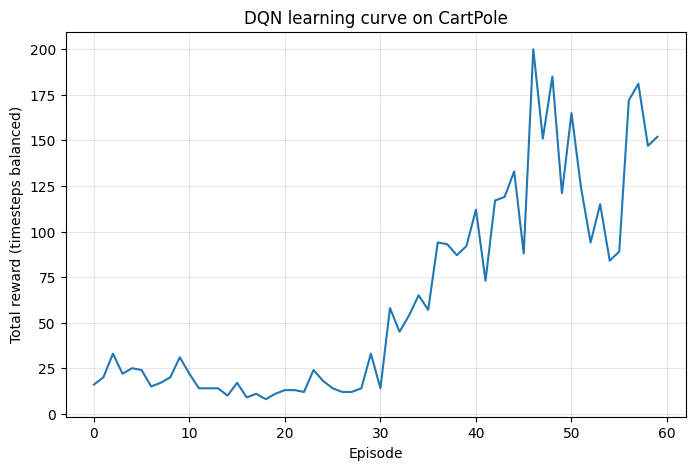

First episode with reward > 50: 31
First episode with reward > 150: 46
Reward variance, first 20 episodes: 46.1
Reward variance, last 20 episodes: 1288.8


In [3]:
if GYM_AVAILABLE and TF_AVAILABLE:
    env = gym.make("CartPole-v1", max_episode_steps=MAX_STEPS)
    rewards_baseline, _ = train_dqn(env, n_episodes=60, epsilon_decay_episodes=45, seed=SEED)
    env.close()

    plt.figure(figsize=(8, 5))
    plt.plot(rewards_baseline)
    plt.xlabel("Episode"); plt.ylabel("Total reward (timesteps balanced)")
    plt.title("DQN learning curve on CartPole")
    plt.grid(alpha=0.3)
    plt.show()

    above_50 = next((i for i, r in enumerate(rewards_baseline) if r > 50), None)
    above_150 = next((i for i, r in enumerate(rewards_baseline) if r > 150), None)
    print(f"First episode with reward > 50: {above_50}")
    print(f"First episode with reward > 150: {above_150}")
    print(f"Reward variance, first 20 episodes: {np.var(rewards_baseline[:20]):.1f}")
    print(f"Reward variance, last 20 episodes: {np.var(rewards_baseline[-20:]):.1f}")


**Answer in this cell:** How many episodes does it take for the agent to achieve sustained balance? Is improvement smooth, or does it show the characteristic RL pattern — irregular improvement with occasional catastrophic failures even late in training? What does the variance comparison (early vs. late episodes) tell you?

## Part 2 — The Exploration Schedule

Re-run training with three epsilon decay schedules: fast decay, medium decay, and slow decay. Plot all three learning curves together.

Training with FAST exploration decay...


Training with MEDIUM exploration decay...


Training with SLOW exploration decay...


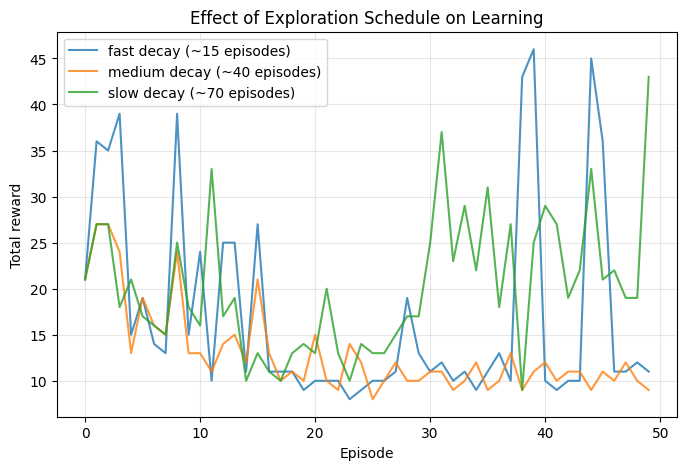

Mean reward, first 20 episodes -- fast: 20.5, medium: 16.4, slow: 18.1
Mean reward, last 20 episodes  -- fast: 17.1, medium: 10.5, slow: 25.0


In [4]:
if GYM_AVAILABLE and TF_AVAILABLE:
    env = gym.make("CartPole-v1", max_episode_steps=MAX_STEPS)
    N_EPISODES = 50
    print("Training with FAST exploration decay...")
    rewards_fast, _ = train_dqn(env, n_episodes=N_EPISODES, epsilon_decay_episodes=10, seed=SEED + 1)
    print("Training with MEDIUM exploration decay...")
    rewards_medium, _ = train_dqn(env, n_episodes=N_EPISODES, epsilon_decay_episodes=25, seed=SEED + 1)
    print("Training with SLOW exploration decay...")
    rewards_slow, _ = train_dqn(env, n_episodes=N_EPISODES, epsilon_decay_episodes=40, seed=SEED + 1)
    env.close()

    plt.figure(figsize=(8, 5))
    plt.plot(rewards_fast, label="fast decay (~15 episodes)", alpha=0.8)
    plt.plot(rewards_medium, label="medium decay (~40 episodes)", alpha=0.8)
    plt.plot(rewards_slow, label="slow decay (~70 episodes)", alpha=0.8)
    plt.xlabel("Episode"); plt.ylabel("Total reward")
    plt.title("Effect of Exploration Schedule on Learning")
    plt.legend(); plt.grid(alpha=0.3)
    plt.show()

    print(f"Mean reward, first 20 episodes -- fast: {np.mean(rewards_fast[:20]):.1f}, "
          f"medium: {np.mean(rewards_medium[:20]):.1f}, slow: {np.mean(rewards_slow[:20]):.1f}")
    print(f"Mean reward, last 20 episodes  -- fast: {np.mean(rewards_fast[-20:]):.1f}, "
          f"medium: {np.mean(rewards_medium[-20:]):.1f}, slow: {np.mean(rewards_slow[-20:]):.1f}")


**Answer in this cell:** Does faster exploitation produce faster early learning? Does slower exploration produce better final performance? Is there a crossover point? Which schedule would you choose for an application where early performance matters (fast deployment)? Which for an application where final performance matters most (high-stakes deployment)?

## Part 3 — Reward Function Effects

Compare three reward variants on the same task: the standard reward, a sparse reward, and a shaped reward with an angle-based bonus.

Training with STANDARD reward...


Training with SPARSE reward...


Training with SHAPED reward...


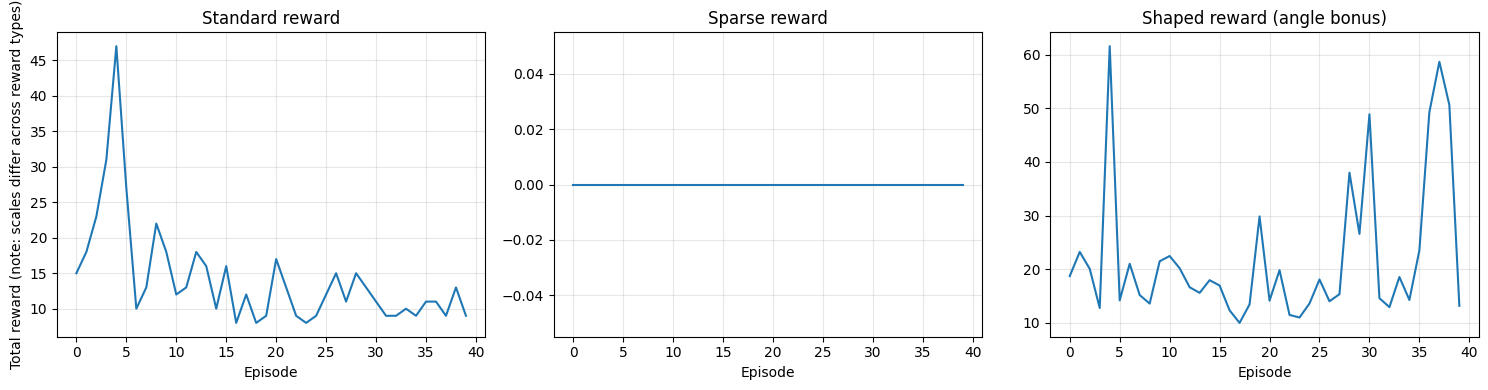

Standard: mean last-10-episode TIMESTEPS balanced = 10.1
Sparse:   mean last-10-episode reward (not directly comparable in scale) = 0.0
Shaped:   mean last-10-episode reward (includes angle bonus) = 30.4


In [5]:
if GYM_AVAILABLE and TF_AVAILABLE:
    import gymnasium as gym
    from gymnasium import Wrapper

    class SparseRewardWrapper(Wrapper):
        def step(self, action):
            obs, reward, terminated, truncated, info = self.env.step(action)
            self.t = getattr(self, "t", 0) + 1
            sparse_reward = 1000.0 if self.t >= int(MAX_STEPS * 0.9) else 0.0
            return obs, sparse_reward, terminated, truncated, info

        def reset(self, **kwargs):
            self.t = 0
            return self.env.reset(**kwargs)

    class ShapedRewardWrapper(Wrapper):
        def step(self, action):
            obs, reward, terminated, truncated, info = self.env.step(action)
            angle = obs[2]  # pole angle from vertical
            bonus = 1.0 - abs(angle) / 0.2095  # closer to vertical -> bigger bonus
            return obs, reward + 0.5 * bonus, terminated, truncated, info

    N_EPISODES = 40
    print("Training with STANDARD reward...")
    env = gym.make("CartPole-v1", max_episode_steps=MAX_STEPS)
    rewards_standard, _ = train_dqn(env, n_episodes=N_EPISODES, epsilon_decay_episodes=30, seed=SEED + 2)
    env.close()

    print("Training with SPARSE reward...")
    env = SparseRewardWrapper(gym.make("CartPole-v1", max_episode_steps=MAX_STEPS))
    rewards_sparse, _ = train_dqn(env, n_episodes=N_EPISODES, epsilon_decay_episodes=30, seed=SEED + 2)
    env.close()

    print("Training with SHAPED reward...")
    env = ShapedRewardWrapper(gym.make("CartPole-v1", max_episode_steps=MAX_STEPS))
    rewards_shaped, agent_shaped = train_dqn(env, n_episodes=N_EPISODES, epsilon_decay_episodes=30, seed=SEED + 2)
    env.close()

    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
    axes[0].plot(rewards_standard); axes[0].set_title("Standard reward")
    axes[1].plot(rewards_sparse); axes[1].set_title("Sparse reward")
    axes[2].plot(rewards_shaped); axes[2].set_title("Shaped reward (angle bonus)")
    for ax in axes:
        ax.set_xlabel("Episode"); ax.grid(alpha=0.3)
    axes[0].set_ylabel("Total reward (note: scales differ across reward types)")
    plt.tight_layout()
    plt.show()

    print(f"Standard: mean last-10-episode TIMESTEPS balanced = {np.mean(rewards_standard[-10:]):.1f}")
    print(f"Sparse:   mean last-10-episode reward (not directly comparable in scale) = {np.mean(rewards_sparse[-10:]):.1f}")
    print(f"Shaped:   mean last-10-episode reward (includes angle bonus) = {np.mean(rewards_shaped[-10:]):.1f}")


**For the shaped reward condition:** does the agent appear to develop behaviors that maximize the angle bonus specifically, in ways that might not be optimal for the true goal of sustained balance? (Hint: compare the shaped agent's raw episode length, if you log it separately, to its shaped reward total — a large gap between the two is a sign the bonus is being optimized somewhat independently of the underlying task.)

## Reflection (200-300 words)

"You observed that the shaped reward condition may produce faster learning than the standard reward, but potentially through behaviors that optimize the shaping bonus specifically rather than the underlying balance task. This is a small-scale instance of reward hacking: the agent optimizes what it was given, not exactly what was intended.

Now return to your MIPDS decision-making layer design. Your reward function document includes a 'What This Reward Does Not Capture' section. Based on what you observed in this exploration — how shaping can produce behaviors the designer did not anticipate, how agents optimize for the measurement rather than the underlying goal — revise and extend that section.

Identify the two most plausible reward-hacking behaviors your MIPDS reward function might produce, and one monitoring signal you would track to detect each one in production." 

**Your reflection (edit this cell):**

_Write your 200-300 word reflection here._